# Chapter 039 — Numerical Stability

> **Prerequisites:** ch038 (Precision and Floating Point Errors — machine epsilon, cancellation, condition number), ch026 (Real Numbers — float64)
> **You will learn:**
> - The difference between numerical stability (algorithm property) and ill-conditioning (problem property)
> - Forward vs backward stability: two distinct ways an algorithm can go wrong
> - Why iterative algorithms can amplify or suppress errors at each step
> - Concrete examples: unstable recurrences, stable vs unstable square root sequences
> - How to measure the stability of an algorithm empirically
>
> **Environment:** Python 3.x, numpy, matplotlib

---
## 1. Concept

Numerical stability is a property of an *algorithm*, not a number. It answers: does this algorithm produce results close to the exact answer when computed with finite-precision arithmetic?

Two distinct failure modes:

**Ill-conditioning** is a property of the *problem*. A problem is ill-conditioned when small changes in the input produce large changes in the output — regardless of which algorithm solves it. You cannot fix ill-conditioning by choosing a better algorithm; you can only report that the answer is inherently uncertain given the input precision.

**Numerical instability** is a property of the *algorithm*. An algorithm is unstable when it amplifies rounding errors beyond what the problem's condition number requires. A better algorithm exists that would give accurate results for the same problem.

Examples:
- Evaluating a polynomial near a root where the root is very sensitive to coefficients: *ill-conditioned problem*.
- Computing the same polynomial using Horner's method vs naive power summation: *algorithm stability question* (Horner is more stable).
- The recurrence eₙ = 1 − (5/6)eₙ₋₁ vs eₙ = 2eₙ₋₁ + ... for computing integrals: *algorithm stability*.

**Why this matters for ML:** Gradient descent, matrix inversion, and eigenvalue computation are all iterative. Error can grow exponentially (unstable), decay exponentially (stable), or stay bounded (marginally stable). An unstable training algorithm diverges.

---
## 2. Intuition & Mental Models

**Physical analogy — pendulum equilibria:** A ball at the bottom of a bowl is stable: small perturbations return it to equilibrium. A ball balanced on top of a hill is unstable: infinitesimal perturbations grow exponentially. Numerical stability is the same question for sequences of numbers: do errors decay back to zero, or do they grow?

**Computational analogy — error as a signal:** At each step of an iterative algorithm, the error ε_k either gets multiplied by a number |λ| < 1 (stable, error shrinks) or by |λ| > 1 (unstable, error grows). After k steps, the error is ~ε_0 × λᵏ. If |λ| = 1.1 and k = 100, even a tiny initial error ε_0 = 10⁻¹⁵ grows to ε_0 × 1.1¹⁰⁰ ≈ 1.37 × 10⁻¹¹ — not catastrophic here, but with |λ| = 2 the result is ~10¹⁵ times the initial error, which completely destroys the computation.

**Forward vs backward stability:**
- *Forward stability*: the computed answer is close to the true answer. This is what you want.
- *Backward stability*: the computed answer is the *exact* answer to a *slightly perturbed* problem. IEEE 754 arithmetic is backward-stable for individual operations. Backward stability + condition number ≤ forward stability.

Recall from ch038 (Precision and Floating Point Errors): each floating-point operation satisfies `fl(x ⊕ y) = (x ⊕ y)(1 + δ)` with |δ| ≤ ε_m/2. This is backward stability at the level of a single operation.

---
## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_16196\1032257342.py:59: UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16196\1032257342.py:59: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


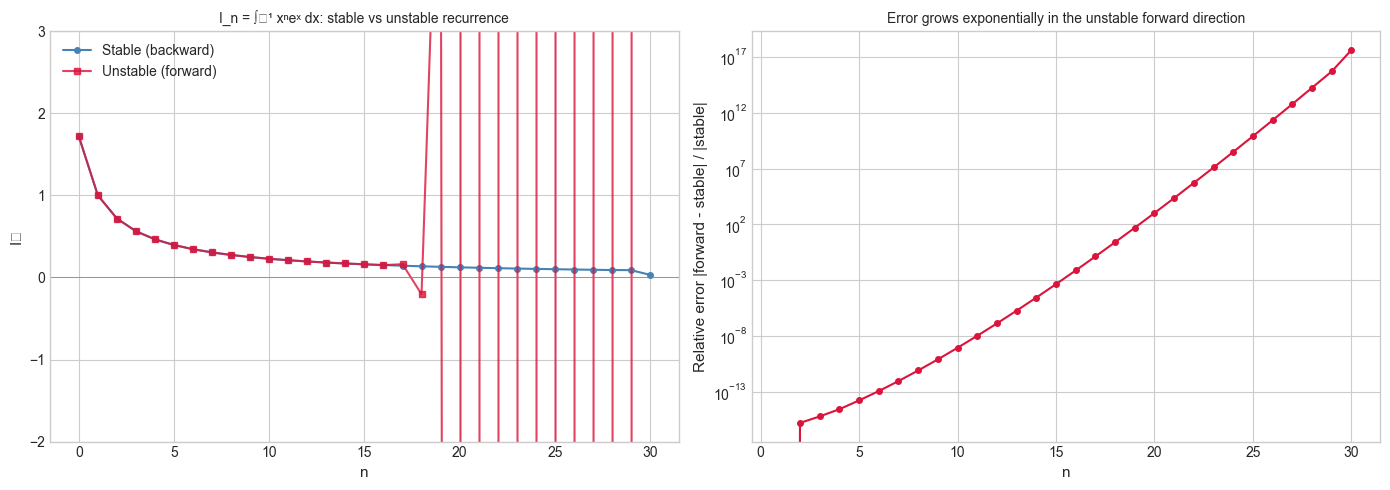

In [1]:
# --- Visualization: Stable vs unstable recurrences ---
# Classic example: computing I_n = integral_0^1 x^n * e^x dx
# Exact recurrence (integration by parts): I_n = e - n * I_{n-1}
# This is UNSTABLE in the forward direction (n growing).
# Stable direction: compute backwards from a high starting estimate.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

e = np.e
N_TERMS = 30

# True values via scipy-free numerical integration (Gaussian quadrature estimate)
# We use the stable backward recurrence as the 'true' reference
def stable_backward(n_max, start_estimate=0.5):
    """Compute I_0..I_{n_max} using backward stable recurrence."""
    # Start from I_{n_max} = start_estimate, recurse backward: I_{n-1} = (e - I_n) / n
    I = np.zeros(n_max + 1)
    I[n_max] = start_estimate  # rough guess — error will wash out going backward
    for k in range(n_max, 0, -1):
        I[k-1] = (e - I[k]) / k
    return I

def unstable_forward(n_max):
    """Compute I_0..I_{n_max} using forward recurrence: I_n = e - n * I_{n-1}."""
    I = np.zeros(n_max + 1)
    I[0] = e - 1  # exact: I_0 = integral_0^1 e^x dx = e - 1
    for n in range(1, n_max + 1):
        I[n] = e - n * I[n-1]
    return I

I_stable = stable_backward(N_TERMS, start_estimate=1 / (N_TERMS + 1))  # rough guess
I_unstable = unstable_forward(N_TERMS)

ns = np.arange(N_TERMS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ns, I_stable, 'o-', color='steelblue', markersize=4, label='Stable (backward)')
axes[0].plot(ns, I_unstable, 's-', color='crimson', markersize=4, label='Unstable (forward)', alpha=0.8)
axes[0].set_ylim(-2, 3)
axes[0].set_xlabel('n', fontsize=11)
axes[0].set_ylabel('Iₙ', fontsize=11)
axes[0].set_title('I_n = ∫₀¹ xⁿeˣ dx: stable vs unstable recurrence', fontsize=10)
axes[0].legend()
axes[0].axhline(0, color='gray', linewidth=0.5)

# Error growth in the forward direction
# Relative error: compare to stable solution as reference
valid = I_stable != 0
rel_err = np.where(valid, np.abs(I_unstable - I_stable) / np.abs(I_stable), np.nan)
axes[1].semilogy(ns[1:], rel_err[1:], 'o-', color='crimson', markersize=4)
axes[1].set_xlabel('n', fontsize=11)
axes[1].set_ylabel('Relative error |forward - stable| / |stable|', fontsize=11)
axes[1].set_title('Error grows exponentially in the unstable forward direction', fontsize=10)

plt.tight_layout()
plt.show()

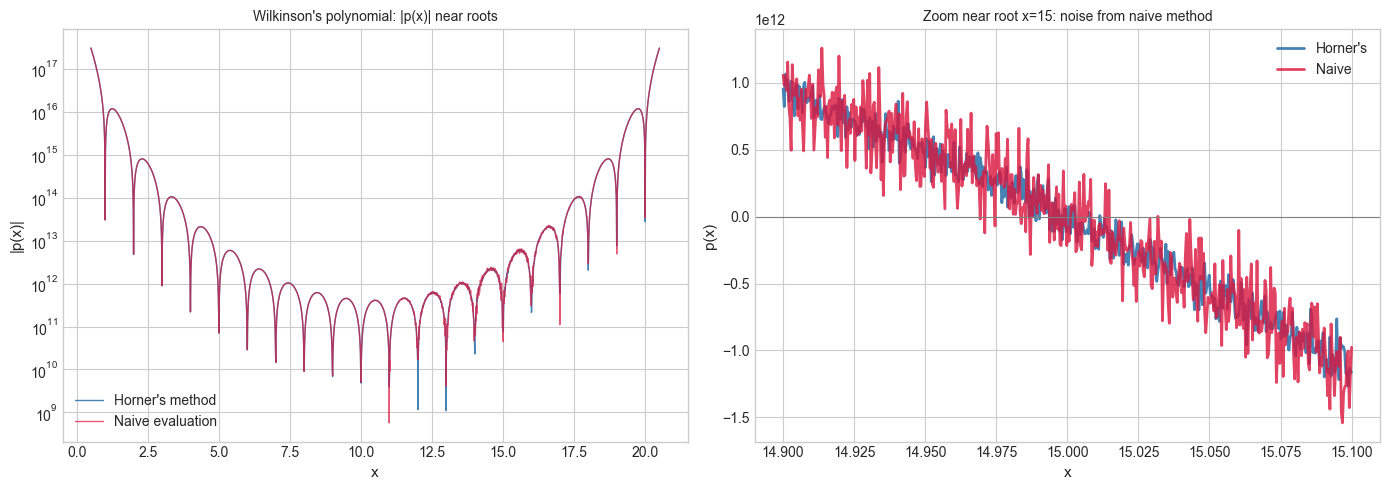

In [2]:
# --- Visualization: Horner's method vs naive polynomial evaluation ---
# Horner's method evaluates p(x) = a_0 + a_1*x + ... + a_n*x^n
# using n multiplications and n additions — and with better numerical stability.
# Naive method computes each power x^k separately, accumulating rounding errors.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Wilkinson's polynomial: (x-1)(x-2)...(x-20), roots at 1,2,...,20
# Expanded coefficients (computed exactly)
roots = list(range(1, 21))
coeffs = np.poly(roots)  # numpy gives coefficients from highest to lowest degree

def horner(coeffs_high_to_low, x):
    """Evaluate polynomial using Horner's method."""
    result = coeffs_high_to_low[0]
    for c in coeffs_high_to_low[1:]:
        result = result * x + c
    return result

def naive_eval(coeffs_high_to_low, x):
    """Evaluate polynomial naively: compute each power separately."""
    n = len(coeffs_high_to_low) - 1
    result = 0.0
    for i, c in enumerate(coeffs_high_to_low):
        result += c * x**(n - i)
    return result

# Evaluate near a root (x=10.5 should give a clear positive value;
# at x=10, should give 0 but floating-point makes it noisy)
x_vals = np.linspace(0.5, 20.5, 2000)
y_horner = np.array([horner(coeffs, x) for x in x_vals])
y_naive  = np.array([naive_eval(coeffs, x) for x in x_vals])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full view
axes[0].semilogy(x_vals, np.abs(y_horner) + 1e-10, color='steelblue', lw=1, label="Horner's method")
axes[0].semilogy(x_vals, np.abs(y_naive) + 1e-10, color='crimson', lw=1, alpha=0.7, label='Naive evaluation')
axes[0].set_xlabel('x', fontsize=11)
axes[0].set_ylabel('|p(x)|', fontsize=11)
axes[0].set_title("Wilkinson's polynomial: |p(x)| near roots", fontsize=10)
axes[0].legend()

# Zoom near a root
x_zoom = np.linspace(14.9, 15.1, 500)
axes[1].plot(x_zoom, [horner(coeffs, x) for x in x_zoom], color='steelblue', lw=2, label="Horner's")
axes[1].plot(x_zoom, [naive_eval(coeffs, x) for x in x_zoom], color='crimson', lw=2, alpha=0.8, label='Naive')
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_xlabel('x', fontsize=11)
axes[1].set_ylabel('p(x)', fontsize=11)
axes[1].set_title('Zoom near root x=15: noise from naive method', fontsize=10)
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4. Mathematical Formulation

**Condition number of a problem.** For a function f(x), the relative condition number is:
$$\kappa_f(x) = \left|\frac{x \cdot f'(x)}{f(x)}\right|$$
An output relative error ≤ κ_f(x) · ε_input is unavoidable regardless of algorithm.

**Forward stability.** Algorithm A is forward stable for problem f if:
$$\frac{|\tilde{f}(x) - f(x)|}{|f(x)|} \leq C \cdot \kappa_f(x) \cdot \varepsilon_m$$
where C is a modest constant (ideally O(n) for n-step algorithms).

**Backward stability.** Algorithm A is backward stable if it computes the exact answer to a nearby problem:
$$\tilde{f}(x) = f(x + \delta x), \quad \frac{|\delta x|}{|x|} \leq C \cdot \varepsilon_m$$
Backward stability + condition number ≤ forward stability (this is a theorem).

**Error amplification in recurrences.** For a linear recurrence eₙ = λ eₙ₋₁ + ..., if |λ| > 1 then errors grow as |λ|ⁿ. If |λ| < 1, errors decay. For the integral recurrence Iₙ = e − n·Iₙ₋₁: the amplification factor at step n is n. After k steps the error is e₀ · k! — catastrophic.

**Horner's method.** Rewrites p(x) = a₀ + a₁x + a₂x² + ... + aₙxⁿ as:
$$p(x) = a_0 + x(a_1 + x(a_2 + \cdots + x(a_{n-1} + x \cdot a_n)\cdots))$$
This requires n multiplications and n additions — no powers — and its backward error is O(nε_m), optimal for polynomial evaluation.

---
## 5. Python Implementation

In [3]:
# --- Implementation: Numerical Stability Toolkit ---

import numpy as np

def horner_eval(coeffs_low_to_high, x):
    """
    Evaluate polynomial using Horner's method.

    Args:
        coeffs_low_to_high: coefficients [a_0, a_1, ..., a_n]
                            where polynomial = a_0 + a_1*x + ... + a_n*x^n
        x: evaluation point (scalar or array)

    Returns:
        p(x) computed with O(n) operations and O(n*eps_m) backward error
    """
    result = coeffs_low_to_high[-1]  # start from highest-degree coefficient
    for c in reversed(coeffs_low_to_high[:-1]):
        result = result * x + c
    return result


def condition_number_scalar(f, df, x):
    """
    Compute the relative condition number of scalar function f at point x.

    Args:
        f: callable, the function
        df: callable, the derivative f'
        x: evaluation point

    Returns:
        kappa = |x * f'(x) / f(x)|
    """
    fx = f(x)
    if abs(fx) < 1e-300:
        return np.inf  # near a root: condition number diverges
    return abs(x * df(x) / fx)


def measure_algorithm_error(algorithm, exact, x_values):
    """
    Measure relative error of an algorithm over a range of inputs.

    Args:
        algorithm: callable(x) -> approximate result
        exact: callable(x) -> exact result
        x_values: array of test points

    Returns:
        array of relative errors
    """
    errors = []
    for x in x_values:
        approx = algorithm(x)
        true = exact(x)
        if abs(true) > 1e-300:
            errors.append(abs(approx - true) / abs(true))
        else:
            errors.append(abs(approx - true))
    return np.array(errors)


# --- Validation ---
# Horner vs naive for p(x) = 1 + x + x^2 + x^3 + x^4
coeffs = [1, 1, 1, 1, 1]  # a_0, ..., a_4 (low to high)
x = 2.0
horner_result = horner_eval(coeffs, x)
# Geometric sum: (x^5 - 1)/(x - 1) = 31 for x=2
print(f"p(2) = 1+2+4+8+16 = {horner_result}  (expected: 31)")

# Condition number of f(x) = x^2 - 1 at x = 1 (near root)
f  = lambda x: x**2 - 1
df = lambda x: 2*x
for xval in [0.5, 1.0, 1.001, 2.0, 10.0]:
    k = condition_number_scalar(f, df, xval)
    print(f"  kappa at x={xval:.3f}: {k:.4f}  {'← ILL-CONDITIONED near root' if k > 100 else ''}")

p(2) = 1+2+4+8+16 = 31.0  (expected: 31)
  kappa at x=0.500: 0.6667  
  kappa at x=1.000: inf  ← ILL-CONDITIONED near root
  kappa at x=1.001: 1001.5002  ← ILL-CONDITIONED near root
  kappa at x=2.000: 2.6667  
  kappa at x=10.000: 2.0202  


---
## 6. Experiments

C:\Users\user\AppData\Local\Temp\ipykernel_16196\4171038152.py:40: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


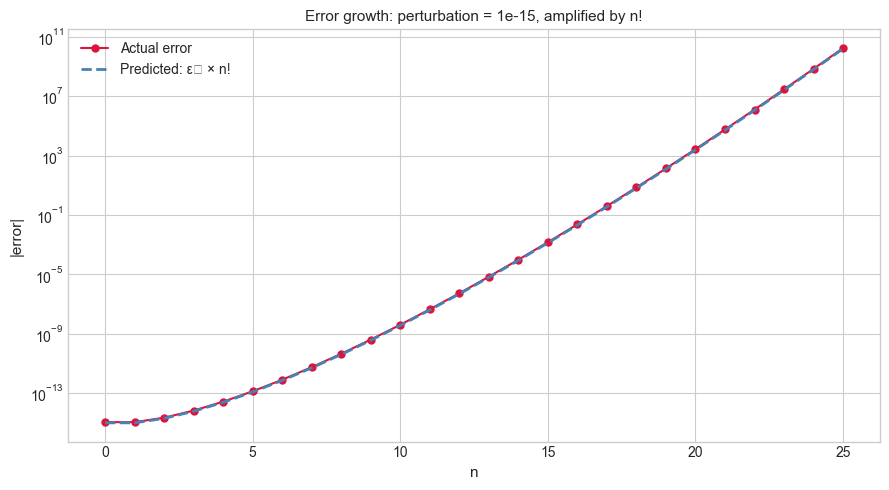

In [4]:
# --- Experiment 1: Error growth in the unstable integral recurrence ---
# Hypothesis: starting from I_0 = e - 1 with a tiny perturbation,
# the error grows as n! through the forward recurrence.
# Try changing: PERTURBATION to see how even machine epsilon causes divergence.

import numpy as np

e = np.e
N_TERMS = 25    # <-- modify this
PERTURBATION = 1e-15  # <-- modify this (try 0, 1e-15, 1e-10)

def forward_recurrence(n_max, I0_error=0.0):
    """I_n = e - n * I_{n-1}, starting from I_0 = (e-1) + error."""
    I = np.zeros(n_max + 1)
    I[0] = e - 1 + I0_error
    for n in range(1, n_max + 1):
        I[n] = e - n * I[n-1]
    return I

I_exact = forward_recurrence(N_TERMS, I0_error=0.0)
I_perturbed = forward_recurrence(N_TERMS, I0_error=PERTURBATION)

errors = np.abs(I_perturbed - I_exact)

# Theoretical prediction: error_n = PERTURBATION * n!
import math
predicted = np.array([abs(PERTURBATION) * math.factorial(n) for n in range(N_TERMS + 1)])

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(9, 5))
ns = np.arange(N_TERMS + 1)
ax.semilogy(ns, errors + 1e-20, 'o-', color='crimson', markersize=5, label='Actual error')
ax.semilogy(ns, predicted + 1e-20, '--', color='steelblue', lw=2, label='Predicted: ε₀ × n!')
ax.set_xlabel('n', fontsize=11)
ax.set_ylabel('|error|', fontsize=11)
ax.set_title(f'Error growth: perturbation = {PERTURBATION:.0e}, amplified by n!', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# --- Experiment 2: Stable backward recurrence — error suppression ---
# Hypothesis: starting from a WRONG estimate at high n and recursing backward,
# the error shrinks by 1/n at each step — total error is O(eps_m).
# Try changing: START_ERROR to see how robustly backward recurrence suppresses it.

import numpy as np

e = np.e
N_MAX = 30         # <-- modify this
START_ERROR = 1.0  # <-- modify this (try 0.1, 1.0, 10.0 — the backward method absorbs all of these)

def backward_recurrence(n_max, start_estimate_error=0.0):
    """I_{n-1} = (e - I_n) / n, starting from rough estimate at n_max."""
    I_true_at_n = 1 / (n_max + 1)  # rough but reasonable estimate
    I = np.zeros(n_max + 1)
    I[n_max] = I_true_at_n + start_estimate_error  # intentionally wrong
    for k in range(n_max, 0, -1):
        I[k-1] = (e - I[k]) / k
    return I

I_exact   = backward_recurrence(N_MAX, start_estimate_error=0.0)
I_wrong   = backward_recurrence(N_MAX, start_estimate_error=START_ERROR)

errors = np.abs(I_wrong - I_exact)

print(f"Starting error at n={N_MAX}: {START_ERROR}")
print(f"Resulting error at n=0: {errors[0]:.4e}")
print(f"Error suppression factor: {START_ERROR / (errors[0] + 1e-300):.2e}")
print("\nErrors across n:")
for n in [N_MAX, N_MAX-5, N_MAX//2, 5, 0]:
    print(f"  n={n:2d}: error = {errors[n]:.4e}")

Starting error at n=30: 1.0
Resulting error at n=0: 0.0000e+00
Error suppression factor: 1.00e+300

Errors across n:
  n=30: error = 1.0000e+00
  n=25: error = 5.8477e-08
  n=15: error = 0.0000e+00
  n= 5: error = 0.0000e+00
  n= 0: error = 0.0000e+00


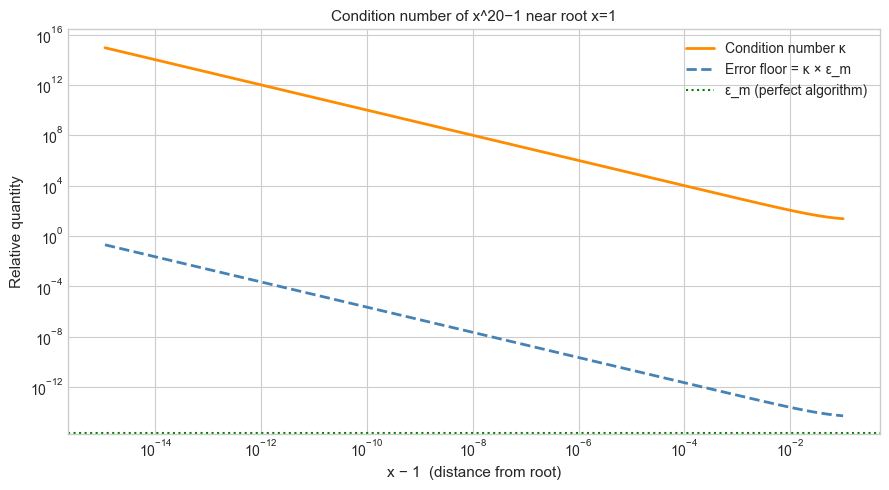

In [6]:
# --- Experiment 3: Condition number vs algorithmic error ---
# Hypothesis: for well-conditioned problems, both naive and stable algorithms agree.
# For ill-conditioned problems, unstable algorithms amplify error far beyond κ * eps_m.
# Try changing: POWER to control how ill-conditioned the problem is.

import numpy as np

# Evaluate f(x) = x^POWER - 1 near its root x=1
# Condition number near x=1: kappa = |x * f'(x) / f(x)| = |x * POWER * x^(POWER-1) / (x^POWER - 1)|
# As x -> 1, kappa -> POWER / |x-1|  (grows as we approach the root)

POWER = 20   # <-- modify this

def f(x): return x**POWER - 1
def df(x): return POWER * x**(POWER-1)

x_test_points = 1.0 + np.logspace(-15, -1, 100)

kappas = np.array([abs(x * df(x) / f(x)) if abs(f(x)) > 1e-300 else np.inf for x in x_test_points])
floor_errors = kappas * np.finfo(float).eps  # minimum achievable relative error

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(x_test_points - 1, kappas, color='darkorange', lw=2, label='Condition number κ')
ax.loglog(x_test_points - 1, floor_errors, '--', color='steelblue', lw=2, label='Error floor = κ × ε_m')
ax.axhline(np.finfo(float).eps, color='green', linestyle=':', lw=1.5, label='ε_m (perfect algorithm)')
ax.set_xlabel('x − 1  (distance from root)', fontsize=11)
ax.set_ylabel('Relative quantity', fontsize=11)
ax.set_title(f'Condition number of x^{POWER}−1 near root x=1', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 7. Exercises

**Easy 1.** Implement Horner's method for a polynomial represented as a list `[a_n, a_{n-1}, ..., a_1, a_0]` (highest degree first). Evaluate p(x) = 3x⁴ − 5x³ + 2x² − x + 7 at x = 1.5 using your Horner function and using direct computation. Verify they match. *(Expected: single float)*

**Easy 2.** Compute the condition number of f(x) = sin(x) at x = 0, x = π/4, and x = π. Which evaluation point is most ill-conditioned? Explain why. *(Hint: κ = |x·cos(x)/sin(x)|)*

**Medium 1.** The recurrence for Fibonacci-like sequences F_n = a·F_{n-1} + b·F_{n-2} can be stable or unstable depending on the roots of λ² = aλ + b. Write a function that classifies the stability of this recurrence given a and b, and verify with experiments for (a=1, b=1) Fibonacci, (a=2, b=−1) — roots 1 and 1 (borderline), and (a=3, b=−2) — roots 1 and 2 (unstable).

**Medium 2.** Implement the stable formula for `log1p(x) = log(1 + x)` for small x without using `math.log1p`. Use the Taylor series `x - x²/2 + x³/3 - ...` with enough terms. Compare your implementation to `math.log1p(x)` and `math.log(1+x)` for x = 1e-10 to show that naive `log(1+x)` suffers cancellation.

**Hard.** Investigate Wilkinson's polynomial W(x) = ∏(x−k) for k=1..20. Perturb the coefficient of x¹⁹ by 2⁻²³ (the float32 machine epsilon). Compute the roots of the perturbed polynomial using numpy and compare to the unperturbed roots. This is Wilkinson's famous 1963 example of an extremely ill-conditioned polynomial. Report the condition number of the root-finding problem and explain why small coefficient changes cause such large root displacements.

---
## 8. Mini Project — Stable vs Unstable Summation Benchmark

In [ ]:
# --- Mini Project: Comprehensive Summation Benchmark ---
# Problem:
#   Summation of n floating-point numbers is a fundamental operation.
#   Different algorithms trade accuracy against speed.
#   Build a benchmark that compares 5 methods across multiple distributions
#   and produces a 'stability vs speed' report.
#
# Methods to compare:
#   1. Python built-in sum() — left-to-right
#   2. numpy sum (default) — may use SIMD/chunked but not compensated
#   3. Kahan compensated sum
#   4. Sorted sum (ascending order)
#   5. math.fsum — exact (uses extended precision internally)

import numpy as np
import math
import time
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

def kahan_sum(values):
    s, c = 0.0, 0.0
    for x in values:
        y = x - c
        t = s + y
        c = (t - s) - y
        s = t
    return s

# Test scenarios
N = 100_000  # <-- modify this
rng = np.random.default_rng(42)

scenarios = {
    'Uniform [0,1]':         rng.uniform(0, 1, N),
    'Mixed large+small':     np.concatenate([rng.uniform(1e6, 2e6, N//2), rng.uniform(0, 1, N//2)]),
    'Alternating sign':      np.where(np.arange(N) % 2 == 0, rng.uniform(1, 2, N), -rng.uniform(1, 2, N)),
    'Exponential':           rng.exponential(1.0, N),
}

methods = [
    ('Built-in sum',   lambda arr: sum(arr)),
    ('numpy sum',      lambda arr: float(np.sum(arr))),
    ('Kahan sum',      kahan_sum),
    ('Sorted sum',     lambda arr: float(np.sum(np.sort(arr)))),
    ('math.fsum',      math.fsum),
]

print(f"{'Scenario':<25} | {'Method':<15} | {'Rel. Error':>12} | {'Time (ms)':>10}")
print('-' * 72)

for scenario_name, arr in scenarios.items():
    exact = math.fsum(arr)  # best available reference
    for method_name, fn in methods[:-1]:  # skip fsum in comparison (it's the reference)
        REPS = 3
        t0 = time.perf_counter()
        result = None
        for _ in range(REPS):
            result = fn(arr)
        t1 = time.perf_counter()
        rel_err = abs(result - exact) / (abs(exact) + 1e-300)
        time_ms = (t1 - t0) / REPS * 1000
        print(f"{scenario_name:<25} | {method_name:<15} | {rel_err:>12.4e} | {time_ms:>10.3f}")
    print()

---
## 9. Chapter Summary & Connections

**What was covered:**
- Numerical stability is a property of an *algorithm*; ill-conditioning is a property of a *problem*. These are distinct and must not be confused.
- Errors in recurrences grow as |λ|ⁿ where λ is the amplification factor per step. Running a recurrence in the stable direction (backward) suppresses errors instead.
- Horner's method evaluates polynomials with O(nε_m) backward error — optimal among polynomial evaluation algorithms.
- Condition number κ defines the unavoidable error floor: even a perfect algorithm cannot beat κ·ε_m relative error.
- Forward stability = backward stability × condition number is the fundamental theorem of numerical analysis.

**Backward connection:** This chapter formalizes the algorithm-level analysis implied by ch038 (Precision and Floating Point Errors), which introduced machine epsilon and per-operation error bounds.

**Forward connections:**
- *(ch040 — Computational Number Systems)*: extends precision analysis to alternative number systems (fixed-point, posit numbers, arbitrary precision), where the stability-vs-speed trade-off takes different forms.
- *(ch175 — Gaussian Elimination)*: LU decomposition with partial pivoting is backward stable; without pivoting it is not. The proof uses exactly the amplification analysis introduced here.
- *(ch208 — Automatic Differentiation)*: AD accumulates floating-point error in derivative computations; the stability of AD vs finite differences is an application of this chapter's framework.

**Going deeper:** *Accuracy and Stability of Numerical Algorithms* by Nicholas Higham is the definitive reference. Chapter 3 covers Horner's method; Chapter 4 covers the integral recurrence example used here.